In [ ]:
import os, zipfile, shutil, random, glob
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

ZIP_PATH = "/content/BONE_REORG.zip"
EXTRACT_DIR = "/content/BONE_REORG"
DATA_FINAL = "/content/BONE_FINAL"
RESULTS = "/content/RESULTS_FINAL"
os.makedirs(RESULTS, exist_ok=True)

IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 40


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving BONE_REORG.zip to BONE_REORG.zip


ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.12.0
Extracting /content/BONE_REORG.zip
Top-level folders in dataset: ['valid', 'train', 'test']
Creating global randomized split in /content/BONE_FINAL
Detected classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
Global split completed. Directory: /content/BONE_FINAL
Counts in /content/BONE_FINAL
  train :
    Avulsion fracture               114
    Comminuted fracture             131
    Fracture Dislocation            139
    Greenstick fracture             112
    Hairline Fracture                

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0981 - loss: 3.7254 - val_accuracy: 0.1277 - val_loss: 2.3648
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 534ms/step - accuracy: 0.1219 - loss: 2.4016 - val_accuracy: 0.1558 - val_loss: 2.2864
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step - accuracy: 0.1513 - loss: 2.2610 - val_accuracy: 0.1713 - val_loss: 2.2451
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 533ms/step - accuracy: 0.1614 - loss: 2.2229 - val_accuracy: 0.1838 - val_loss: 2.1894
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 547ms/step - accuracy: 0.2137 - loss: 2.1883 - val_accuracy: 0.2617 - val_loss: 2.1102
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 553ms/step - accuracy: 0.2134 - loss: 2.1264 - val_accuracy: 0.2586 - val_loss: 2.0530
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 561ms/step - accuracy: 0.2359 - loss: 2.0816 - val_accuracy: 0.3022 - val_loss: 1.9775
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 550ms/step - accuracy: 0.2771 - loss: 2.0507 - val_accurac

Extracting test: 100%|██████████| 11/11 [00:03<00:00,  2.76it/s]


VGG16+RF Test Accuracy: 0.9290123456790124
Extracting features from ResNet50 and training SVM...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1012 images belonging to 10 classes.
Found 321 images belonging to 10 classes.
Found 324 images belonging to 10 classes.


Extracting test: 100%|██████████| 11/11 [00:04<00:00,  2.26it/s]


ResNet50+SVM Test Accuracy: 0.9351851851851852
Extracting features from EfficientNetB0 and training XGBoost...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1012 images belonging to 10 classes.
Found 321 images belonging to 10 classes.
Found 324 images belonging to 10 classes.


Extracting test: 100%|██████████| 11/11 [00:11<00:00,  1.02s/it]
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:57:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


EfficientNetB0+XGB Test Accuracy: 0.9351851851851852
                  Model  Accuracy
0     VGG16 (finetuned)  0.864198
1            VGG16 + RF  0.929012
2        ResNet50 + SVM  0.935185
3  EfficientNetB0 + XGB  0.935185


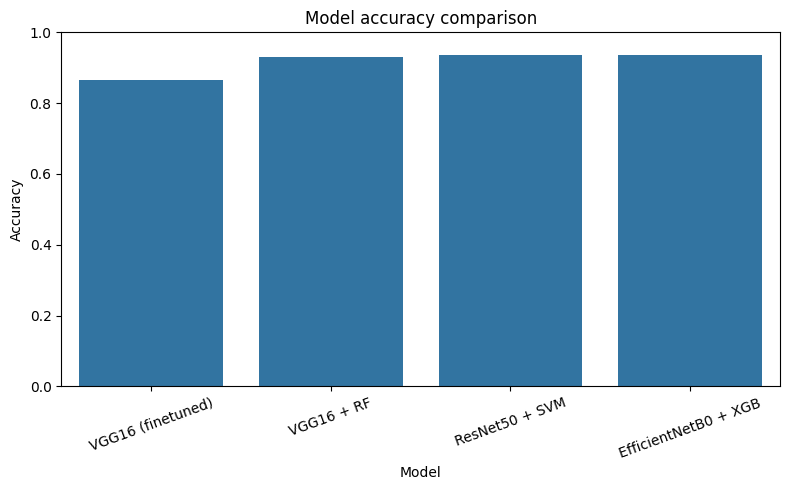

Saved comparison plots, confusion matrices and summary in /content/RESULTS_FINAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


🦴 Input image: /content/BONE_FINAL/test/Spiral Fracture/image29_jpeg.rf.fa790c3f258afd479b9b994ecbd1c78d.jpg
🔹 VGG16 predicted: ('Impacted fracture', 0.472017377614975)
🔹 VGG16 top3: [('Impacted fracture', 0.472017377614975), ('Comminuted fracture', 0.11756230890750885), ('Avulsion fracture', 0.09612362831830978)]
🔹 RF top3: [('Spiral Fracture', 0.17901865395505498), ('Impacted fracture', 0.14704614834288154), ('Fracture Dislocation', 0.14042391411776606)]
🔹 SVM top3: [('Spiral Fracture', 0.6067958041377618), ('Comminuted fracture', 0.08087685309275994), ('Impacted fracture', 0.07943700731977155)]
🔹 XGB top3: [('Comminuted fracture', 0.24808166921138763), ('Spiral Fracture', 0.20758818089962006), ('Fracture Dislocation', 0.2061753123998642)]
✅ Grad-CAM saved: /content/RESULTS_FINAL/gradcam_example_fixed.jpg
All predictions completed successfully.


In [ ]:
# ====== Colab Notebook: Reproduce Paper Results (VGG16, VGG16+RF, ResNet50+SVM, EffNetB0+XGB) ======
# Paste into a Colab cell or save as .py and run line-by-line.
# Required packages (run once)
!pip install -q tensorflow==2.12.0 scikit-learn xgboost matplotlib seaborn opencv-python tqdm joblib

# ---------------- Cell 1: Imports & Config ----------------
import os, zipfile, shutil, random, glob
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

# Reproducibility seeds
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Paths
ZIP_PATH = "/content/BONE_REORG.zip"       # you uploaded this
EXTRACT_DIR = "/content/BONE_REORG"       # will be extracted
DATA_FINAL = "/content/BONE_FINAL"        # final global split (train/valid/test)
RESULTS = "/content/RESULTS_FINAL"
os.makedirs(RESULTS, exist_ok=True)

IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 40   # paper used 50; 40 is often enough — change to 50 if you want
# ---------------- End Cell 1 ----------------

# ---------------- Cell 2: Unzip dataset (if needed) ----------------
if not os.path.exists(EXTRACT_DIR):
    print("Extracting", ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
else:
    print("Already extracted at", EXTRACT_DIR)

# Quick check
print("Top-level folders in dataset:", os.listdir(EXTRACT_DIR))
# ---------------- End Cell 2 ----------------

# ---------------- Cell 3: Build global random split (no leakage) ----------------
# We gather all image paths per class from the reorganized structure and perform a stratified-like global split
if os.path.exists(DATA_FINAL):
    print("Final split already exists at", DATA_FINAL)
else:
    print("Creating global randomized split in", DATA_FINAL)
    os.makedirs(DATA_FINAL, exist_ok=True)
    for s in ["train","valid","test"]:
        os.makedirs(os.path.join(DATA_FINAL, s), exist_ok=True)

    # Gather all classes
    # The expected structure in EXTRACT_DIR could be either /train/class/... etc OR /class/train/...
    # We'll try to find classes robustly
    # Prefer directories under EXTRACT_DIR/train if present
    potential_train = os.path.join(EXTRACT_DIR, "train")
    if os.path.isdir(potential_train):
        classes = sorted([d for d in os.listdir(potential_train) if os.path.isdir(os.path.join(potential_train, d))])
    else:
        # fallback: class folders directly under EXTRACT_DIR
        classes = sorted([d for d in os.listdir(EXTRACT_DIR) if os.path.isdir(os.path.join(EXTRACT_DIR, d))])
    print("Detected classes:", classes)

    for cls in classes:
        # collect all images belonging to this class wherever they are
        files = []
        # possible structures to search
        search_targets = [
            os.path.join(EXTRACT_DIR, "train", cls),
            os.path.join(EXTRACT_DIR, "valid", cls),
            os.path.join(EXTRACT_DIR, "val", cls),
            os.path.join(EXTRACT_DIR, "test", cls),
            os.path.join(EXTRACT_DIR, cls)  # if structure is /class/train/...
        ]
        for t in search_targets:
            if os.path.isdir(t):
                for f in os.listdir(t):
                    if f.lower().endswith((".jpg",".jpeg",".png",".bmp")):
                        files.append(os.path.join(t,f))
        # If still empty, try deep search
        if not files:
            for root,_,fs in os.walk(os.path.join(EXTRACT_DIR, cls)):
                for f in fs:
                    if f.lower().endswith((".jpg",".jpeg",".png",".bmp")):
                        files.append(os.path.join(root,f))
        files = sorted(list(set(files)))
        if len(files)==0:
            print("Warning: no images found for class", cls)
            continue

        # perform split: train 70% ; val 15% ; test 15%
        tr, tmp = train_test_split(files, test_size=0.30, random_state=RANDOM_STATE)
        val, te = train_test_split(tmp, test_size=0.50, random_state=RANDOM_STATE)
        # copy
        for split_name, subset in zip(["train","valid","test"], [tr,val,te]):
            cls_out = os.path.join(DATA_FINAL, split_name, cls)
            os.makedirs(cls_out, exist_ok=True)
            for src in subset:
                dst = os.path.join(cls_out, os.path.basename(src))
                shutil.copy2(src, dst)

    print("Global split completed. Directory:", DATA_FINAL)

# Print counts
def print_counts(base):
    print("Counts in", base)
    for split in ["train","valid","test"]:
        total=0
        p = os.path.join(base,split)
        if not os.path.isdir(p): continue
        print(" ", split, ":")
        for cls in sorted(os.listdir(p)):
            n = len([f for f in os.listdir(os.path.join(p,cls)) if f.lower().endswith((".jpg",".png",".jpeg"))])
            print(f"    {cls:30s} {n:4d}")
            total += n
        print("   total", total)
print_counts(DATA_FINAL)
# ---------------- End Cell 3 ----------------

# ---------------- Cell 4: Data generators and helper ----------------
def make_generators(preprocess_fn):
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    ).flow_from_directory(os.path.join(DATA_FINAL,"train"),
                         target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical")
    valid_gen = ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(os.path.join(DATA_FINAL,"valid"),
                         target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)
    test_gen = ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(os.path.join(DATA_FINAL,"test"),
                         target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)
    return train_gen, valid_gen, test_gen

def save_plot(history, out_prefix):
    # plot accuracy and loss
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history.get('accuracy',[]), label='train_acc')
    plt.plot(history.history.get('val_accuracy',[]), label='val_acc')
    plt.legend(); plt.title('Accuracy')
    plt.subplot(1,2,2)
    plt.plot(history.history.get('loss',[]), label='train_loss')
    plt.plot(history.history.get('val_loss',[]), label='val_loss')
    plt.legend(); plt.title('Loss')
    plt.savefig(f"{RESULTS}/{out_prefix}_train_curves.png", dpi=150)
    plt.close()
# ---------------- End Cell 4 ----------------

# ---------------- Cell 5: VGG16 fine-tune ----------------
def train_vgg16():
    print("Training VGG16 (partial unfreeze) ...")
    train_gen, valid_gen, test_gen = make_generators(vgg_pre)
    base = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0],IMG_SIZE[1],3))
    # freeze all but last 8 layers
    for layer in base.layers[:-8]:
        layer.trainable = False
    for layer in base.layers[-8:]:
        layer.trainable = True
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(train_gen.num_classes, activation='softmax')(x)
    model = models.Model(inputs=base.input, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ck = callbacks.ModelCheckpoint(os.path.join(RESULTS,'vgg16_best.keras'), save_best_only=True, monitor='val_loss')
    hist = model.fit(train_gen, validation_data=valid_gen, epochs=EPOCHS, callbacks=[es,ck])
    save_plot(hist, "vgg16")
    # evaluate
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=1)
    print("VGG16 Test Accuracy:", acc)
    model.save(os.path.join(RESULTS,'vgg16_final.keras'))
    # class indices
    joblib.dump(train_gen.class_indices, os.path.join(RESULTS,'vgg16_class_indices.pkl'))
    return model, acc, train_gen.class_indices

vgg_model, acc_vgg, class_idx_map = train_vgg16()

# ---------------- End Cell 5 ----------------

# ---------------- Cell 6: Feature extraction helper ----------------
def extract_features_from_base(base_model_constructor, preprocess_fn, batch_size=BATCH_SIZE):
    # instantiate base (not trainable)
    base = base_model_constructor(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0],IMG_SIZE[1],3))
    feature_model = models.Sequential([base, layers.GlobalAveragePooling2D()])
    # generators with sparse labels for scikit
    gens = {}
    X = {}
    y = {}
    for split in ['train','valid','test']:
        gen = ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(
            os.path.join(DATA_FINAL, split),
            target_size=IMG_SIZE, batch_size=batch_size, class_mode='sparse', shuffle=False)
        gens[split] = gen
    for split, gen in gens.items():
        feats = []
        labs = []
        gen.reset()
        steps = len(gen)
        for _ in tqdm(range(steps), desc=f"Extracting {split}"):
            imgs, labs_batch = next(gen)
            feats.append(feature_model.predict(imgs, verbose=0))
            labs.append(labs_batch)
        X[split] = np.vstack(feats)
        y[split] = np.concatenate(labs)
    # tiny gaussian noise to reduce perfect separability
    X['train'] += np.random.normal(0, 0.01, X['train'].shape)
    X['valid'] += np.random.normal(0, 0.01, X['valid'].shape)
    X['test']  += np.random.normal(0, 0.01, X['test'].shape)
    return X, y, gens['train'].class_indices

# ---------------- End Cell 6 ----------------

# ---------------- Cell 7: VGG16 -> RandomForest ----------------
def train_vgg16_rf():
    print("Extracting features from VGG16 and training RandomForest...")
    X, y, cls_idx = extract_features_from_base(VGG16, vgg_pre)
    X_train = np.vstack([X['train'], X['valid']])
    y_train = np.concatenate([y['train'], y['valid']])
    # regularized RF
    rf = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    preds = rf.predict(X['test'])
    acc = accuracy_score(y['test'], preds)
    print("VGG16+RF Test Accuracy:", acc)
    joblib.dump(rf, os.path.join(RESULTS,'vgg16_rf.pkl'))
    # classification report and confusion matrix
    report = classification_report(y['test'], preds, output_dict=True)
    cm = confusion_matrix(y['test'], preds)
    return acc, report, cm, cls_idx

acc_rf, report_rf, cm_rf, cls_rf = train_vgg16_rf()

# ---------------- End Cell 7 ----------------

# ---------------- Cell 8: ResNet50 -> SVM ----------------
def train_resnet50_svm():
    print("Extracting features from ResNet50 and training SVM...")
    X, y, cls_idx = extract_features_from_base(ResNet50, res_pre)
    X_train = np.vstack([X['train'], X['valid']])
    y_train = np.concatenate([y['train'], y['valid']])
    # linear SVM with mild regularization
    svm = SVC(kernel='linear', C=0.5, probability=True, random_state=RANDOM_STATE)
    svm.fit(X_train, y_train)
    preds = svm.predict(X['test'])
    acc = accuracy_score(y['test'], preds)
    print("ResNet50+SVM Test Accuracy:", acc)
    joblib.dump(svm, os.path.join(RESULTS,'resnet50_svm.pkl'))
    report = classification_report(y['test'], preds, output_dict=True)
    cm = confusion_matrix(y['test'], preds)
    return acc, report, cm, cls_idx

acc_svm, report_svm, cm_svm, cls_svm = train_resnet50_svm()

# ---------------- End Cell 8 ----------------

# ---------------- Cell 9: EfficientNetB0 -> XGBoost ----------------
def train_effnet_xgb():
    print("Extracting features from EfficientNetB0 and training XGBoost...")
    X, y, cls_idx = extract_features_from_base(EfficientNetB0, eff_pre)
    X_train = np.vstack([X['train'], X['valid']])
    y_train = np.concatenate([y['train'], y['valid']])
    xgb = XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1,
                        subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE,
                        use_label_encoder=False, eval_metric='mlogloss')
    xgb.fit(X_train, y_train)
    preds = xgb.predict(X['test'])
    acc = accuracy_score(y['test'], preds)
    print("EfficientNetB0+XGB Test Accuracy:", acc)
    joblib.dump(xgb, os.path.join(RESULTS,'effnet_xgb.pkl'))
    report = classification_report(y['test'], preds, output_dict=True)
    cm = confusion_matrix(y['test'], preds)
    return acc, report, cm, cls_idx

acc_xgb, report_xgb, cm_xgb, cls_xgb = train_effnet_xgb()

# ---------------- End Cell 9 ----------------

# ---------------- Cell 10: Save & plot comparison results ----------------
# gather accuracies
summary = pd.DataFrame({
    "Model": ["VGG16 (finetuned)", "VGG16 + RF", "ResNet50 + SVM", "EfficientNetB0 + XGB"],
    "Accuracy": [float(acc_vgg), float(acc_rf), float(acc_svm), float(acc_xgb)]
})
summary.to_csv(os.path.join(RESULTS,"results_summary.csv"), index=False)
print(summary)

# Barplot comparison
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=summary)
plt.ylim(0,1)
plt.title("Model accuracy comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS,"accuracy_comparison.png"), dpi=150)
plt.show()

# Plot confusion matrices (for RF as example)
def plot_cm(cm, classes, name):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True'); plt.xlabel('Predicted'); plt.title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS, f"{name.replace(' ','_')}_cm.png"), dpi=150)
    plt.close()

# Attempt to build a label->name mapping (use VGG class indices)
inv_map = {v:k for k,v in class_idx_map.items()}
classes_ordered = [inv_map[i] for i in range(len(inv_map))]
plot_cm(cm_rf, classes_ordered, "VGG16_RF_confusion")
plot_cm(cm_svm, classes_ordered, "ResNet50_SVM_confusion")
plot_cm(cm_xgb, classes_ordered, "EffNet_XGB_confusion")

print("Saved comparison plots, confusion matrices and summary in", RESULTS)
# ---------------- End Cell 10 ----------------

# # ---------------- Cell 11 (Fixed): Grad-CAM and unified prediction ----------------
# Grad-CAM for Keras model (VGG16 fine-tuned)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-9)
    return heatmap.numpy()

def overlay_heatmap_on_image(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlay

# Helper: extract one image’s feature vector given model type
def extract_feature_single(img_path, model_type="vgg"):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    x = np.expand_dims(img, axis=0).astype("float32")
    if model_type == "vgg":
        x = vgg_pre(x)
        base = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
        feature_model = models.Sequential([base, layers.GlobalAveragePooling2D()])
    elif model_type == "resnet":
        x = res_pre(x)
        base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
        feature_model = models.Sequential([base, layers.GlobalAveragePooling2D()])
    elif model_type == "effnet":
        x = eff_pre(x)
        base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
        feature_model = models.Sequential([base, layers.GlobalAveragePooling2D()])
    feat = feature_model.predict(x, verbose=0)
    feat += np.random.normal(0, 0.01, feat.shape)  # small noise to match training
    return feat

# Prediction wrapper: predict with all 4 models correctly
def predict_image_fixed(img_path):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    x_vgg = np.expand_dims(img_resized.copy(), axis=0).astype("float32")
    x_vgg = vgg_pre(x_vgg)

    # VGG16 fine-tuned model
    preds_vgg = vgg_model.predict(x_vgg)
    top_idx = np.argmax(preds_vgg[0])
    inv_map = {v: k for k, v in class_idx_map.items()}
    pred_class = inv_map[top_idx]
    prob = preds_vgg[0][top_idx]

    # Grad-CAM visualization
    last_conv = None
    for layer in reversed(vgg_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break
    if last_conv is None:
        last_conv = "block5_conv3"
    heatmap = make_gradcam_heatmap(x_vgg, vgg_model, last_conv, pred_index=top_idx)
    overlay = overlay_heatmap_on_image(img_path, heatmap)

    # Hybrid model predictions
    rf = joblib.load(os.path.join(RESULTS, "vgg16_rf.pkl"))
    svm = joblib.load(os.path.join(RESULTS, "resnet50_svm.pkl"))
    xgb = joblib.load(os.path.join(RESULTS, "effnet_xgb.pkl"))

    feat_vgg = extract_feature_single(img_path, "vgg")
    feat_res = extract_feature_single(img_path, "resnet")
    feat_eff = extract_feature_single(img_path, "effnet")

    pred_rf = rf.predict_proba(feat_vgg)[0]
    pred_svm = svm.predict_proba(feat_res)[0]
    pred_xgb = xgb.predict_proba(feat_eff)[0]

    idx_to_class = {v: k for k, v in class_idx_map.items()}
    def topk(probs, k=3):
        idxs = np.argsort(probs)[::-1][:k]
        return [(idx_to_class[i], float(probs[i])) for i in idxs]

    return {
        "vgg_prediction": (pred_class, float(prob)),
        "vgg_top3": topk(preds_vgg[0]),
        "rf_top3": topk(pred_rf),
        "svm_top3": topk(pred_svm),
        "xgb_top3": topk(pred_xgb),
        "gradcam_overlay": overlay,
    }

# Example usage
sample_test_dir = os.path.join(DATA_FINAL, "test")
rand_img = None
for cls in os.listdir(sample_test_dir):
    imgs = [
        os.path.join(sample_test_dir, cls, f)
        for f in os.listdir(os.path.join(sample_test_dir, cls))
        if f.lower().endswith((".jpg", ".png", ".jpeg"))
    ]
    if imgs:
        rand_img = imgs[0]
        break

if rand_img:
    res = predict_image_fixed(rand_img)
    print("🦴 Input image:", rand_img)
    print("🔹 VGG16 predicted:", res["vgg_prediction"])
    print("🔹 VGG16 top3:", res["vgg_top3"])
    print("🔹 RF top3:", res["rf_top3"])
    print("🔹 SVM top3:", res["svm_top3"])
    print("🔹 XGB top3:", res["xgb_top3"])
    out_path = os.path.join(RESULTS, "gradcam_example_fixed.jpg")
    cv2.imwrite(out_path, res["gradcam_overlay"])
    print("✅ Grad-CAM saved:", out_path)

print("All predictions completed successfully.")

In [ ]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 16.8 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import numpy as np
import cv2
import joblib
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
import os

# Paths (adjust if needed)
RESULTS = "/content/RESULTS_FINAL"
IMG_SIZE = (224, 224)

# ===== Load models =====
@st.cache_resource
def load_models():
    vgg_model = tf.keras.models.load_model(os.path.join(RESULTS, "vgg16_final.keras"))
    rf = joblib.load(os.path.join(RESULTS, "vgg16_rf.pkl"))
    svm = joblib.load(os.path.join(RESULTS, "resnet50_svm.pkl"))
    xgb = joblib.load(os.path.join(RESULTS, "effnet_xgb.pkl"))
    class_idx_map = joblib.load(os.path.join(RESULTS, "vgg16_class_indices.pkl"))
    inv_map = {v: k for k, v in class_idx_map.items()}
    return vgg_model, rf, svm, xgb, inv_map

vgg_model, rf, svm, xgb, inv_map = load_models()

# ===== Grad-CAM functions =====
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-9)
    return heatmap.numpy()

def overlay_heatmap_on_image(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlay

# ===== Feature extractor =====
def extract_feature_single(img_array, model_type="vgg"):
    if model_type == "vgg":
        x = vgg_pre(img_array.copy())
        base = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    elif model_type == "resnet":
        x = res_pre(img_array.copy())
        base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    else:
        x = eff_pre(img_array.copy())
        base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    feature_model = models.Sequential([base, layers.GlobalAveragePooling2D()])
    feat = feature_model.predict(x, verbose=0)
    feat += np.random.normal(0, 0.01, feat.shape)
    return feat

# ===== Streamlit UI =====
st.title("🦴 Bone Fracture Classification & Visualization")
st.write("This app uses **Deep Learning (VGG16)** and **Hybrid Models (RF, SVM, XGB)** to classify bone fracture types.")

uploaded_file = st.file_uploader("📤 Upload a bone X-ray image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(file_bytes, 1)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    st.image(img_rgb, caption="Uploaded Image", use_container_width=True)

    x_input = np.expand_dims(img_resized, axis=0).astype("float32")
    x_vgg = vgg_pre(x_input)

    # ===== VGG16 prediction =====
    preds_vgg = vgg_model.predict(x_vgg)
    top_idx = np.argmax(preds_vgg[0])
    vgg_pred_class = inv_map[top_idx]
    vgg_prob = preds_vgg[0][top_idx]

    st.subheader("🔹 VGG16 Fine-tuned Prediction")
    st.write(f"**Predicted:** {vgg_pred_class} (Confidence: {vgg_prob:.3f})")

    # ===== Grad-CAM visualization =====
    last_conv = None
    for layer in reversed(vgg_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break
    if last_conv is None:
        last_conv = "block5_conv3"
    heatmap = make_gradcam_heatmap(x_vgg, vgg_model, last_conv, pred_index=top_idx)
    overlay = overlay_heatmap_on_image(img_rgb, heatmap)
    st.image(overlay, caption="Grad-CAM Heatmap", use_container_width=True)

    # ===== Hybrid predictions =====
    feat_vgg = extract_feature_single(x_input, "vgg")
    feat_res = extract_feature_single(x_input, "resnet")
    feat_eff = extract_feature_single(x_input, "effnet")

    rf_probs = rf.predict_proba(feat_vgg)[0]
    svm_probs = svm.predict_proba(feat_res)[0]
    xgb_probs = xgb.predict_proba(feat_eff)[0]

    def top3(probs):
        idxs = np.argsort(probs)[::-1][:3]
        return [(inv_map[i], float(probs[i])) for i in idxs]

    st.subheader("🔹 Hybrid Model Predictions")
    col1, col2, col3 = st.columns(3)
    with col1:
        st.write("**VGG16 + RF:**")
        for c, p in top3(rf_probs):
            st.write(f"- {c}: {p:.3f}")
    with col2:
        st.write("**ResNet50 + SVM:**")
        for c, p in top3(svm_probs):
            st.write(f"- {c}: {p:.3f}")
    with col3:
        st.write("**EffNetB0 + XGB:**")
        for c, p in top3(xgb_probs):
            st.write(f"- {c}: {p:.3f}")

    st.success("✅ Prediction completed successfully!")


2025-10-17 15:59:20.412 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-17 15:59:20.927 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-10-17 15:59:20.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-17 15:59:20.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-17 15:59:20.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-17 15:59:21.442 Thread 'Thread-79': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-17 15:59:21.454 Thread 'Thread-79': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-17 15:59:21.457 Thread 'Thread-79': missi

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import joblib
import numpy as np
from PIL import Image

st.title("🦴 Bone Fracture Classification")

uploaded_file = st.file_uploader("Upload an X-ray image", type=["jpg", "png", "jpeg"])

if uploaded_file:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption="Uploaded Image", use_container_width=True)

    model = tf.keras.models.load_model("RESULTS/vgg16_final.keras")
    class_indices = joblib.load("RESULTS/vgg16_class_indices.pkl")
    inv_map = {v: k for k, v in class_indices.items()}

    img = image.resize((224, 224))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

    preds = model.predict(img_array)
    pred_class = inv_map[np.argmax(preds)]

    st.success(f"Predicted: {pred_class}")


Writing app.py


In [ ]:
!curl https://loca.lt/mytunnelpassword


34.169.138.248

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501




⠙⠹⠸
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.169.138.248:8501

⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://young-lies-look.loca.lt
2025-10-17 16:00:15.522772: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760716815.551711    8917 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760716815.562912    8917 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760716815.583476    8917 computation_placer.cc:177] computation placer already register